In [1]:
%run 10_MNESIS_polychronous-chains.ipynb
RECOMPUTE = True

datetag = '2026-04-21'
SNNtorch version 0.9.4
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps


In [2]:
opt = Params()
opt

Params(datetag='2026-04-21', N_neuron=1024, num_delay=41, N_pattern=16, N_time=1000, N_pretime=50, p_A=0.001, seed=2018, lif_beta=0.7, lif_threshold=0.8, learn_beta=False, learn_threshold=False, do_pinv=False, do_deconv=True, num_epochs=16, num_warmup_epochs=16, base_lr=0.001, final_lr=0.0001, delta1=0.01, delta2=5e-05, weight_decay=1e-09, dropout=0.37, alpha_surrogate=15.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=15, fig_height=9, phi=1.61803, N_time_show=400, N_neuron_show=128, N_scan=18)

In [3]:
opt = Params()
hd = HD_SNN(opt, SpikingPattern)
hd.net.to(hd.opt.device)
model_filename = data_cache / f"{hd.opt.datetag}.pth"
model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
hd.net.load_state_dict(model_state_dict)
hd.net.eval()
print(f"Model weights loaded from {model_filename}")

Model weights loaded from ../cached_data/2026-04-21.pth


### testing inference - initiating with a fraction of the trigger duration

In [4]:
with torch.no_grad():
    target = hd.target()
    N_trigger_time = int(hd.opt.num_delay*.75)
    target_full = torch.nn.functional.pad(target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=N_trigger_time, N_time=hd.opt.N_time)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target[:, :, hd.opt.num_delay:]
    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 1.000	 f1_score = 1.000 


Saving as ../figures/trigger_time_init.pdf
Saving as ../figures/trigger_time_init.png
Saving as ../figures/trigger_time_init.svg


(torch.Size([16, 1024, 1100]), 1025.0, 1069.0)

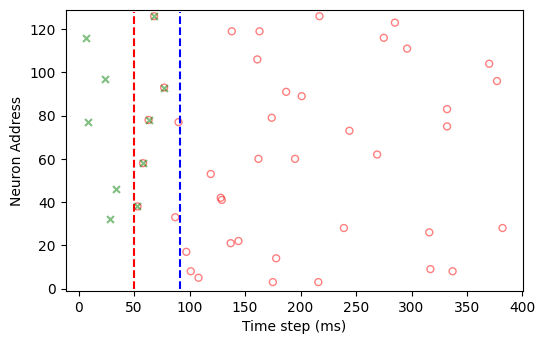

In [5]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
printfig(fig, 'trigger_time_init', fig_width=opt.fig_width, fig_height=opt.fig_width/phi, figpath=figpath)
spikes.shape, spikes[i_pattern, :, :].sum().item(), target[i_pattern, :, :].sum().item()

Saving as ../figures/trigger_time.pdf
Saving as ../figures/trigger_time.png
Saving as ../figures/trigger_time.svg


(torch.Size([16, 1024, 1100]), 1025.0, 1069.0)

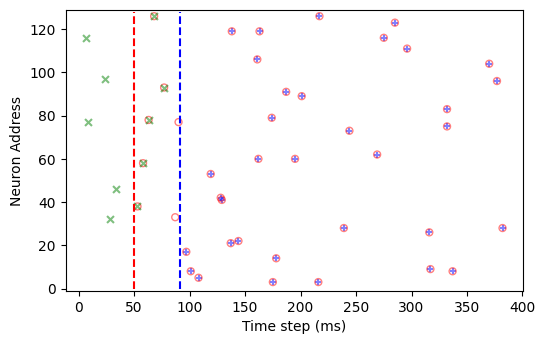

In [6]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
printfig(fig, 'trigger_time', fig_width=opt.fig_width, fig_height=opt.fig_width/phi, figpath=figpath)
spikes.shape, spikes[i_pattern, :, :].sum().item(), target[i_pattern, :, :].sum().item()

In [7]:
# TODO : show how it looks like like in other notebooks

In [8]:
def get_scores_fraction():
    N_trigger_times = np.arange(hd.opt.num_delay)
    scores_np = np.zeros(hd.opt.num_delay)
    for i_trigger_time, N_trigger_time in enumerate(N_trigger_times):
        with torch.no_grad():
            input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=N_trigger_time, N_time=hd.opt.N_time)
            _, _, spikes = hd.forward_pass(input_spikes)
            spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
            target_evoked = target[:, :, hd.opt.num_delay:]

            scores_np[i_trigger_time] = get_f1score(spikes_evoked, target_evoked)

    return N_trigger_times, scores_np

# RECOMPUTE = True # overwriting the defalt value
npy_filename = data_cache / f"{hd.opt.datetag}_trigger_time.npz"
lock_filename = data_cache / npy_filename.with_suffix('.lock')
if RECOMPUTE:
    npy_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    data = np.load(npy_filename)
    N_trigger_times = data['N_trigger_times']
    scores_np = data['scores_np']
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Score weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Score file not found: {model_filename}, evaluating athe score.")
        lock_filename.touch(exist_ok=True)
        ##################
        N_trigger_times, scores_np = get_scores_fraction()
        ##################        
        np.savez(npy_filename, N_trigger_times=N_trigger_times, scores_np=scores_np)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Score file is locked: {lock_filename}, passing.")


Score file not found: ../cached_data/2026-04-21.pth, evaluating athe score.


Saving as ../figures/trigger_time_score.pdf
Saving as ../figures/trigger_time_score.png
Saving as ../figures/trigger_time_score.svg


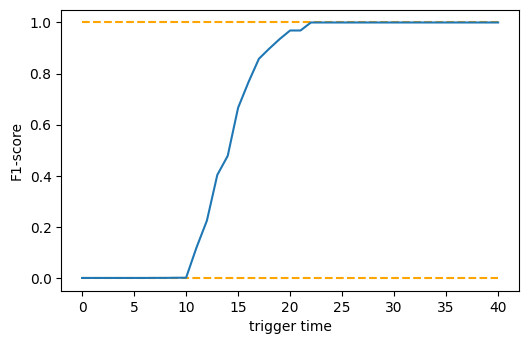

In [9]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
ax.hlines([0, 1], N_trigger_times[0], N_trigger_times[-1], 'orange', ls='--')
ax.plot(N_trigger_times, scores_np)
ax.set_xlabel("trigger time")
ax.set_ylabel("F1-score")

printfig(fig, 'trigger_time_score', fig_width=opt.fig_width, fig_height=opt.fig_width/phi, figpath=figpath)